In [2]:
import numpy as np
import matplotlib.pyplot as plt
from os import listdir
from PIL import Image
from numba import jit

In [3]:
def julia(c, n):
    max_iter = 100
    iters = np.zeros((n,n))
    k_n = 0

    for k in np.linspace(-2,2,n-1):
        p_n = 0
        for p in np.linspace(-2,2,n-1):
            Z = k + p*1.j
            it = 0

            for i in range(1,max_iter):
                Z = Z**2 + c
#                 print(k_n, p_n)
                iters[k_n, p_n] = i

                if np.abs(Z) > 2:
                    break
            p_n += 1

        k_n += 1
    return iters

@jit(nopython=True)
def julia_jit(c, n):
    max_iter = 100
    iters = np.zeros((n,n))
    k_n = 0

    for k in np.linspace(-2,2,n-1):
        p_n = 0
        for p in np.linspace(-2,2,n-1):
            Z = k + p*1.j
            it = 0

            for i in range(1,max_iter):
                Z = Z**2 + c
#                 print(k_n, p_n)
                iters[k_n, p_n] = i

                if np.abs(Z) > 2:
                    break
            p_n += 1

        k_n += 1
    return iters

In [ ]:
c = -0.512511498387847167 + 0.521295573094847167j
n = 1000

iters = julia(c, n)
iters_jit = julia_jit(c, n)

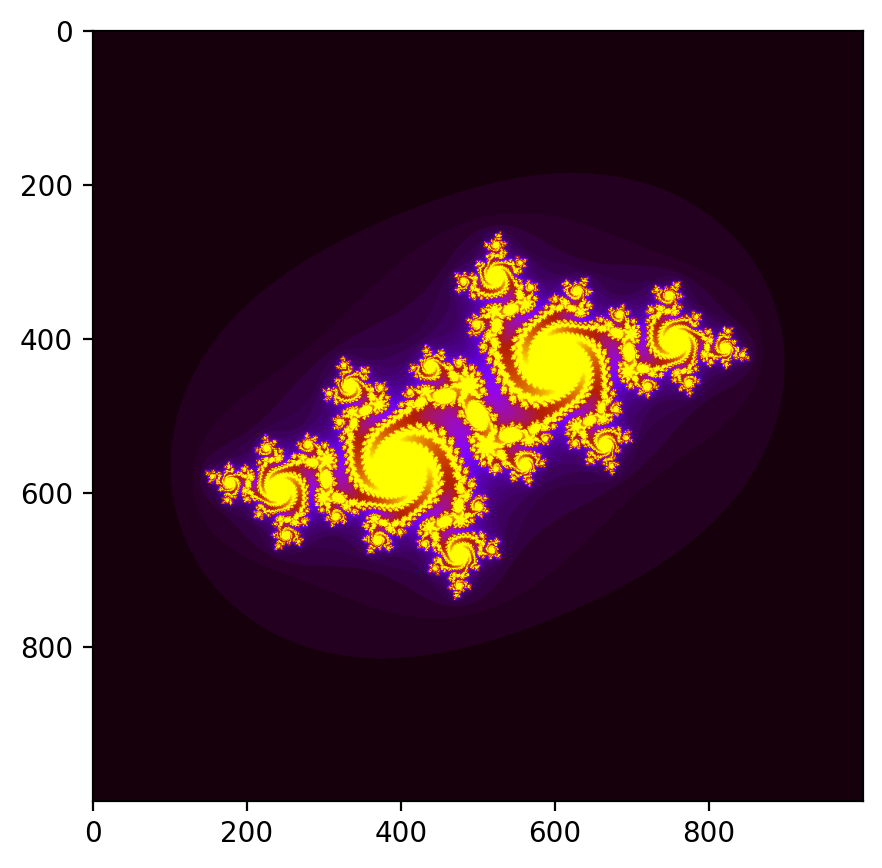

In [ ]:
plt.figure(figsize = (5,5), dpi = 200)
plt.imshow(iters.transpose(), cmap='gnuplot')

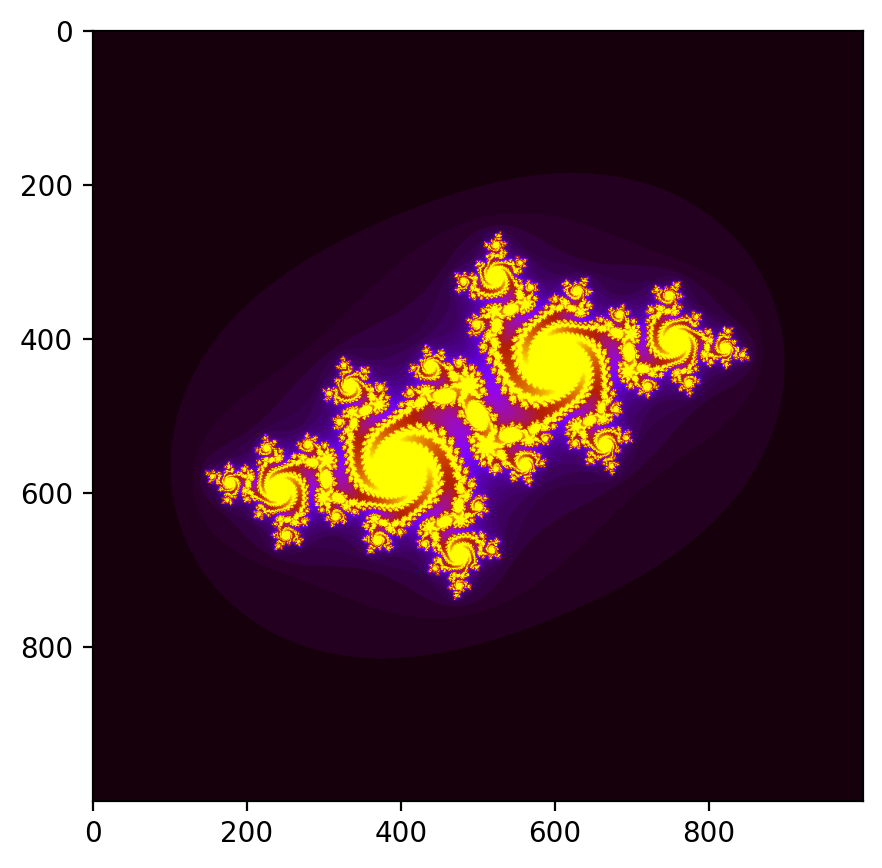

In [ ]:
plt.figure(figsize = (5,5), dpi = 200)
plt.imshow(iters_jit.transpose(), cmap='gnuplot')

In [15]:
Time = np.array([])
Time_numba = np.array([])

c = -0.512511498387847167 + 0.521295573094847167j

rg = range(100,1000,100)

for n in rg:
    time = %timeit -o julia(c, n)
    time_numba = %timeit -o julia_jit(c, n)
    Time = np.append(Time, time.average)
    Time_numba = np.append(Time_numba, time_numba.average)

340 ms ± 67.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.34 ms ± 327 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
682 ms ± 11.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
7.09 ms ± 1.31 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.79 s ± 566 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
14.1 ms ± 368 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
3.19 s ± 668 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
26.9 ms ± 4.96 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
5.15 s ± 915 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
38.6 ms ± 484 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
7.05 s ± 852 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
73.9 ms ± 13.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
9.85 s ± 500 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
75.5 ms ± 1.18 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
12.8 s ± 162 ms per loop (mean ± 

Text(0, 0.5, 'Time')

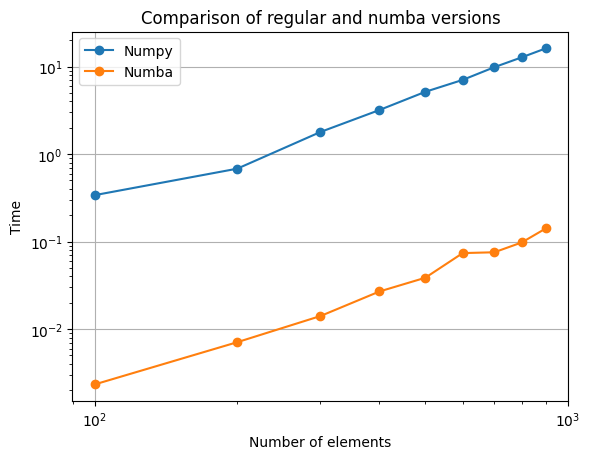

In [22]:
plt.figure()
plt.xscale('log')
plt.yscale('log')
plt.plot(rg, Time, '-o', label = 'Numpy')
plt.plot(rg, Time_numba, '-o', label = 'Numba')
plt.grid()
plt.legend()
plt.title('Comparison of regular and numba versions')
plt.xlabel('Number of elements')
plt.ylabel('Time')
